# Is the magnet effect still alive under Taiwan's 10% price limit?

Re-testing Cho, Russell, Tiao & Tsay, *"The magnet effect of price limits: evidence
from high-frequency data on Taiwan Stock Exchange"*, **Journal of Empirical Finance** 10 (2003) 133–168.

**The original claim.** Stock prices *accelerate* toward the daily price limit as they
approach it. Cho et al. find this strongly for the **upper** bound and only weakly for
the lower bound, and show it survives controls for momentum. Two explanations are
offered in the literature: **illiquidity fear** (traders rush to transact before the
market locks) and **behavioural trend-chasing** (traders buy early to avoid being shut
out of a move).

**What has changed since.** Cho et al. use the **7%** limit regime. TWSE widened the
limit to **10% on 2015-06-01**. A wider band is a weaker constraint: the limit is
reached less often, so both the illiquidity fear and the trend-chasing logic should
be attenuated. Later work ([Chang & Chang](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3942000))
reports the magnet effect *disappears* after the relaxation, especially on the
downside. So this is a genuine open question, not a replication.

**The identification problem, stated up front.** A price limit **censors** the return
distribution. Every day that "wanted" to close +15% is stacked at +10%. That produces
a large spike at the bound *with no magnet whatsoever*. The spike is therefore not
evidence. The magnet hypothesis makes a different and testable prediction:

> the density **just below** the bound is **depleted** — prices are pulled through the
> last stretch rather than resting in it — beyond anything censoring implies.

Everything below is built around separating those two.

**Three sources of identification used here**

1. **Up/down asymmetry.** Censoring is symmetric by construction; a magnet, per the
   original paper, is not. An asymmetric hole below the bound cannot be censoring.
2. **Pseudo-limit placebo.** Re-run every test at a threshold with no regulatory
   meaning (e.g. 7% in the 10% regime). Censoring and fat tails apply there too; only
   the real bound should show the pull. This is the same logic as a calendar-shift
   placebo.
3. **Intraday approach dynamics.** The paper is explicit that daily prices cannot test
   this — acceleration is an intraday phenomenon. Section 7 uses intraday bars.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import limits as L

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})

## 1. Data and the exact limit price

**What this does.** Loads the TWSE daily panel and attaches the **exact** tick-rounded
limit price for every stock-day.

**Why exact limits matter.** TWSE computes the limit from the previous close and rounds
it to the tick, and the tick steps up with price level (0.01 below NT\$10 … 5 above
NT\$1000). So the realised limit return is *not* 10% — it ranges roughly 9.6–10.0%.
A stock closing at 99 has an up-limit of 108.5, i.e. **+9.60%**. That blur lands exactly
on the last percent below the bound, which is the region the whole test depends on.
Using a flat 9.5% cut would mix genuine limit hits with near-misses.

A liquidity floor is applied: on a near-untraded day a single lot can print at the
limit, which would pollute every statistic here.

2,321,362 stock-days | 2015-06-02 .. 2026-09-23 | 1159 stocks
regime
10%    2321362

realised limit return (should span ~9.6-10.0%, NOT a constant 10%):
count    2.321362e+06
mean     9.894000e-02
std      9.400000e-04
min      9.174000e-02
1%       9.589000e-02
25%      9.852000e-02
50%      9.914000e-02
75%      9.964000e-02
99%      1.000000e-01
max      1.000000e-01


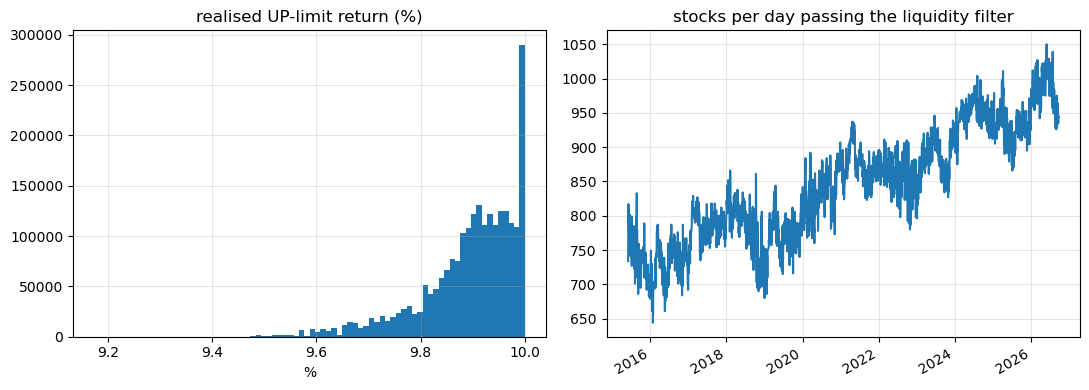

In [2]:
px = L.load_prices("data/prices.csv", min_trade_value=1e6)
px["year"] = px.date.dt.year
px["regime"] = np.where(px.date < L.LIMIT_CHANGE_DATE, "7%", "10%")

print(f"{len(px):,} stock-days | {px.date.min().date()} .. {px.date.max().date()} "
      f"| {px.stock_id.nunique()} stocks")
print(px.regime.value_counts().to_string())

print("\nrealised limit return (should span ~9.6-10.0%, NOT a constant 10%):")
print(px.lim_r_up.describe(percentiles=[.01,.25,.5,.75,.99]).round(5).to_string())

fig, ax = plt.subplots(1, 2)
px.lim_r_up.mul(100).hist(bins=80, ax=ax[0])
ax[0].set_title("realised UP-limit return (%)"); ax[0].set_xlabel("%")
px.groupby("date").size().plot(ax=ax[1], title="stocks per day passing the liquidity filter")
ax[1].set_xlabel("")
plt.tight_layout()

## 2. How often is the limit reached at all?

**What this does.** Counts limit touches (the day's high/low reaches the bound), limit
closes, and **locked** days (open = high = low = limit, i.e. trading is pinned there all
session), by year and by direction.

**Why it matters.** The magnet story needs the bound to be a live possibility. If limit
hits have become rare under the 10% band, any magnet should weaken mechanically —
that is the first-order reason the effect might be dead, and it needs measuring before
anything subtler.

           n  touch_up_per10k  touch_dn_per10k  close_up_per10k  close_dn_per10k  locked_up_per10k
year                                                                                              
2015  109115            134.3            139.6             97.6             70.6               7.8
2016  176067             88.0             32.0             62.8             16.9               6.4
2017  190277            111.0             24.1             80.0             13.6               8.9
2018  190912            127.9             83.3             90.8             43.4               8.5
2019  186410             74.5             18.9             52.6             11.5               6.0
2020  204299            225.9            132.2            161.7             65.1              21.2
2021  213329            245.3             99.8            181.8             44.0              12.4
2022  210409            115.5             38.5             84.0             23.2               6.7
2023  2118

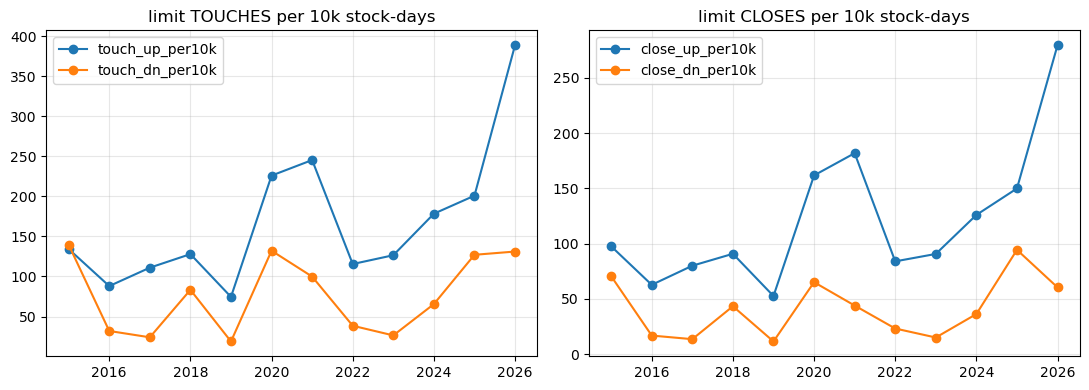

In [3]:
g = px.groupby("year").agg(
    n=("r", "size"),
    touch_up=("touch_up", "sum"), touch_dn=("touch_dn", "sum"),
    close_up=("close_up", "sum"), close_dn=("close_dn", "sum"),
    locked_up=("locked_up", "sum"), locked_dn=("locked_dn", "sum"))
for c in ["touch_up","touch_dn","close_up","close_dn","locked_up","locked_dn"]:
    g[c+"_per10k"] = g[c] / g.n * 1e4
print(g[["n","touch_up_per10k","touch_dn_per10k","close_up_per10k",
         "close_dn_per10k","locked_up_per10k"]].round(1).to_string())

fig, ax = plt.subplots(1, 2)
g[["touch_up_per10k","touch_dn_per10k"]].plot(ax=ax[0], marker="o",
    title="limit TOUCHES per 10k stock-days")
g[["close_up_per10k","close_dn_per10k"]].plot(ax=ax[1], marker="o",
    title="limit CLOSES per 10k stock-days")
for a in ax: a.set_xlabel("")
plt.tight_layout()

print(f"\nup/down ratio of limit closes: {px.close_up.sum()/max(px.close_dn.sum(),1):.2f}x")

## 3. The censoring problem, made visible

**What this does.** Plots the density of closing returns in fine bins approaching the
bound, for both directions, with the bound normalised to 1.0 so stocks with different
tick-rounded limits are comparable.

**How to read it.** Two features matter and they mean different things:

- the **spike at 1.0** — expected under censoring alone, tells us nothing
- the **shape of the approach from 0.8 to 1.0** — this is the magnet's signature

If there is no magnet, the density should decline smoothly into the bound, the way any
fat-tailed return distribution does. If there is a magnet, the last stretch should be
**hollowed out** relative to that smooth decline.

density per 10k, by distance to bound:
         band     UP  DOWN
[0.800,0.850)  12.08 11.62
[0.850,0.900)  10.08  9.54
[0.900,0.940)   6.58  7.31
[0.940,0.970)   5.60  5.72
[0.970,0.995)   3.09  4.09
[0.995,1.010) 117.12 34.49


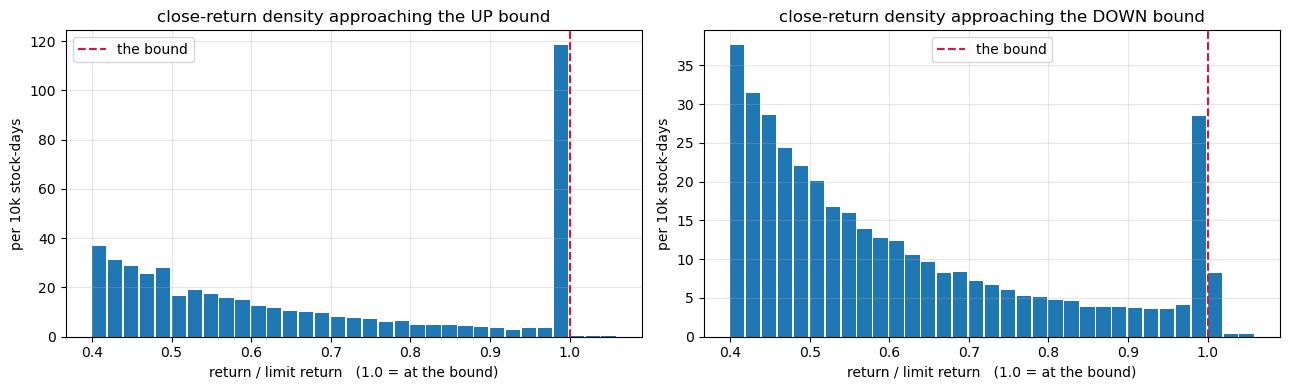

In [4]:
# Normalise: 1.0 = exactly at the bound, in units of the realised limit return.
up = px[px.lim_r_up > 0].copy()
up["z"] = up.r / up.lim_r_up
dn = px[px.lim_r_dn < 0].copy()
dn["z"] = dn.r / dn.lim_r_dn          # positive = toward the DOWN bound

edges = np.arange(0.40, 1.061, 0.02)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, d, lab in [(ax[0], up, "UP bound"), (ax[1], dn, "DOWN bound")]:
    h, _ = np.histogram(d.z.clip(-1, 1.2), bins=edges)
    a.bar(edges[:-1], h / len(d) * 1e4, width=0.018, align="edge")
    a.axvline(1.0, color="crimson", ls="--", label="the bound")
    a.set_title(f"close-return density approaching the {lab}")
    a.set_xlabel("return / limit return   (1.0 = at the bound)")
    a.set_ylabel("per 10k stock-days"); a.legend()
plt.tight_layout()

print("density per 10k, by distance to bound:")
rows=[]
for lo, hi in [(.80,.85),(.85,.90),(.90,.94),(.94,.97),(.97,.995),(.995,1.01)]:
    rows.append({"band": f"[{lo:.3f},{hi:.3f})",
                 "UP": ((up.z>=lo)&(up.z<hi)).sum()/len(up)*1e4,
                 "DOWN": ((dn.z>=lo)&(dn.z<hi)).sum()/len(dn)*1e4})
print(pd.DataFrame(rows).round(2).to_string(index=False))

## 4. Is there a hole below the bound? (censoring-robust test)

**What this does.** Fits the shape of the return density on the **unconstrained**
interior (roughly 0.45–0.80 of the way to the bound), where the limit cannot plausibly
be exerting any pull, then **extrapolates** that fitted decay into the final stretch
(0.85–1.0) and compares it with what is actually observed.

A power-law / exponential decay is fitted in logs, which is the standard shape for a
return tail over a short range.

**Interpretation.**
- observed ≈ extrapolated in the last stretch → **no magnet**, just censoring
- observed **below** extrapolated → **magnet**: mass has been pulled out of the
  approach zone and into the bound
- observed **above** extrapolated → a *cooling-off* effect: prices pile up short of the
  bound rather than being sucked to it

The extrapolation is the weak point of this test and should be treated as suggestive:
it assumes the interior shape continues, which is untestable by construction. The
asymmetry test in section 5 and the placebo in section 6 do not rely on it.

UP     observed   5,863   expected     5,412   ratio  1.08   p = 1.49e-09
DOWN   observed   6,141   expected     4,201   ratio  1.46   p = 0

ratio < 1 = hole below the bound (magnet).  ratio > 1 = pile-up short of it (cooling off).


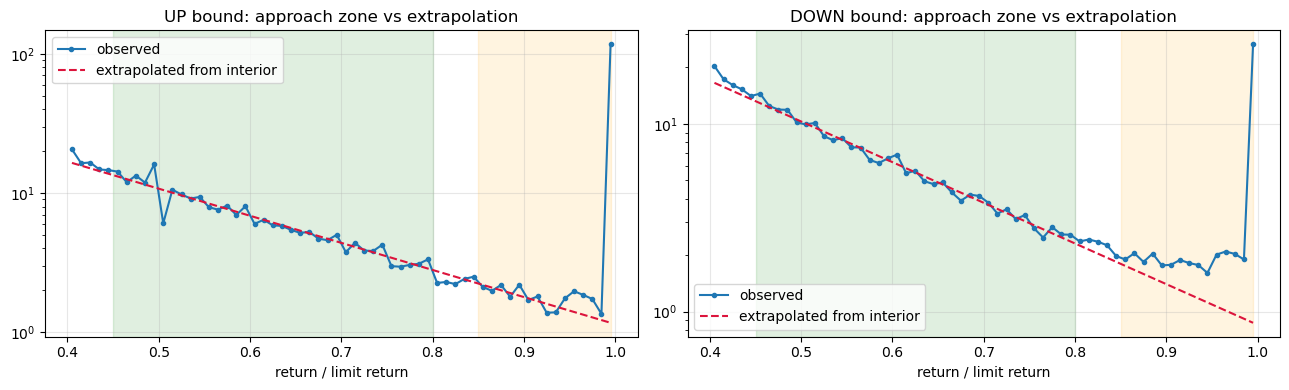

In [5]:
def hole_test(d, fit_lo=0.45, fit_hi=0.80, test_lo=0.85, test_hi=0.995, step=0.01):
    edges = np.arange(0.40, 1.0 + step, step)
    h, _ = np.histogram(d.z, bins=edges)
    mid = (edges[:-1] + edges[1:]) / 2
    dens = h / len(d)

    fit_m = (mid >= fit_lo) & (mid < fit_hi) & (dens > 0)
    # log-linear decay fitted on the unconstrained interior
    b, a = np.polyfit(mid[fit_m], np.log(dens[fit_m]), 1)
    pred = np.exp(a + b * mid)

    test_m = (mid >= test_lo) & (mid < test_hi)
    obs_n = h[test_m].sum()
    exp_n = (pred[test_m] * len(d)).sum()
    # Poisson test on the count in the approach zone
    p = stats.poisson.cdf(obs_n, exp_n) if obs_n < exp_n else 1 - stats.poisson.cdf(obs_n - 1, exp_n)
    return mid, dens, pred, obs_n, exp_n, p * 2

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, d, lab in [(ax[0], up, "UP"), (ax[1], dn, "DOWN")]:
    mid, dens, pred, obs_n, exp_n, p = hole_test(d)
    a.plot(mid, dens * 1e4, "o-", ms=3, label="observed")
    a.plot(mid, pred * 1e4, "--", color="crimson", label="extrapolated from interior")
    a.axvspan(0.85, 0.995, alpha=.12, color="orange")
    a.axvspan(0.45, 0.80, alpha=.12, color="green")
    a.set_yscale("log"); a.legend(); a.set_title(f"{lab} bound: approach zone vs extrapolation")
    a.set_xlabel("return / limit return")
    print(f"{lab:5s}  observed {obs_n:>7,}   expected {exp_n:>9,.0f}   "
          f"ratio {obs_n/exp_n:5.2f}   p = {min(p,1):.3g}")
plt.tight_layout()
print("\nratio < 1 = hole below the bound (magnet).  ratio > 1 = pile-up short of it (cooling off).")

## 5. Up/down asymmetry — identification that does not need a counterfactual

**What this does.** Compares the approach-zone density on the two sides directly.

**Why this is the cleanest test here.** Censoring is **mechanically symmetric**: it
truncates both tails identically. Fat tails and volatility clustering are close to
symmetric too. So a difference between the two sides *cannot* be produced by censoring
and is hard to produce with any mechanical artefact.

Cho et al. found strong acceleration to the ceiling and only weak evidence for the
floor. If that asymmetry is still present under the 10% band, the magnet survives; if
the two sides now look alike, it is gone.

         band  UP_per10k  DOWN_per10k  ratio      z
[0.800,0.850)     12.079       11.622  1.039  1.430
[0.850,0.900)     10.080        9.542  1.056  1.853
[0.900,0.940)      6.582        7.306  0.901 -2.960
[0.940,0.970)      5.600        5.716  0.980 -0.527
[0.970,0.995)      3.093        4.092  0.756 -5.682


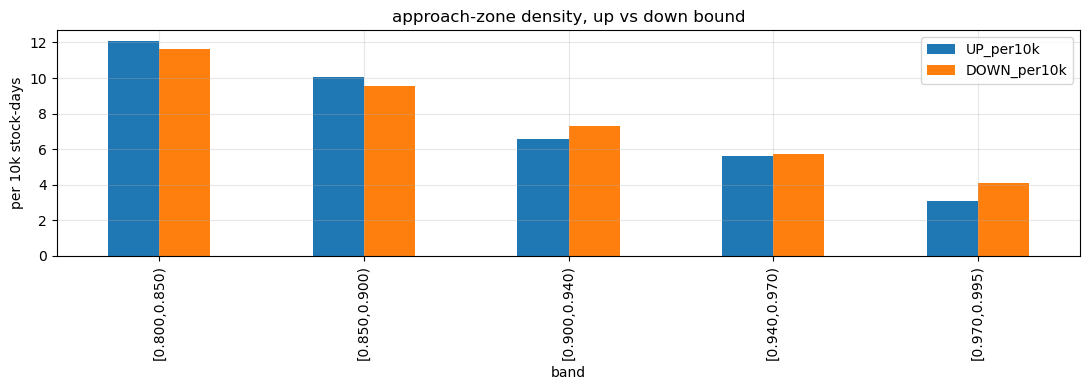

In [6]:
bands = [(.80,.85),(.85,.90),(.90,.94),(.94,.97),(.97,.995)]
rows = []
for lo, hi in bands:
    nu = ((up.z>=lo)&(up.z<hi)).sum(); nd = ((dn.z>=lo)&(dn.z<hi)).sum()
    pu, pd_ = nu/len(up), nd/len(dn)
    # two-proportion z test
    pool = (nu+nd)/(len(up)+len(dn))
    se = np.sqrt(pool*(1-pool)*(1/len(up)+1/len(dn)))
    rows.append({"band": f"[{lo:.3f},{hi:.3f})", "UP_per10k": pu*1e4, "DOWN_per10k": pd_*1e4,
                 "ratio": pu/pd_ if pd_ else np.nan, "z": (pu-pd_)/se if se else np.nan})
res = pd.DataFrame(rows)
print(res.round(3).to_string(index=False))

ax = res.set_index("band")[["UP_per10k","DOWN_per10k"]].plot.bar(
    title="approach-zone density, up vs down bound")
ax.set_ylabel("per 10k stock-days"); plt.tight_layout()

## 6. Pseudo-limit placebo

**What this does.** Repeats the central conditional test —

> given the day's high reached within *x* of a threshold, how often does the day
> **close** at or beyond that threshold?

— at the **real** bound and at **fake** thresholds (5%, 6%, 7%, 8%) that carry no
regulatory meaning under the 10% regime.

**Why this is the strongest test in the notebook.** Fake thresholds are subject to the
same fat tails, the same intraday momentum, the same volatility clustering. What they
lack is the *rule*. If the conditional pull at the true bound is not visibly larger than
at the placebos, there is no magnet — only ordinary trend continuation that would look
identical at any level. This is the same logic as the calendar-shift placebo in the
Gotobi study: keep everything, move only the thing that is supposed to matter.

conditional pull, band = 1.0%

side  threshold      n  P(close beyond)
  up REAL LIMIT  52207           0.5441
  up placebo 5% 228533           0.3375
  up placebo 6% 156091           0.3658
  up placebo 7% 112855           0.3955
  up placebo 8%  84895           0.4312
  dn REAL LIMIT  25116           0.3767
  dn placebo 5% 155856           0.3475
  dn placebo 6%  97134           0.3695
  dn placebo 7%  64643           0.3832
  dn placebo 8%  45457           0.3933


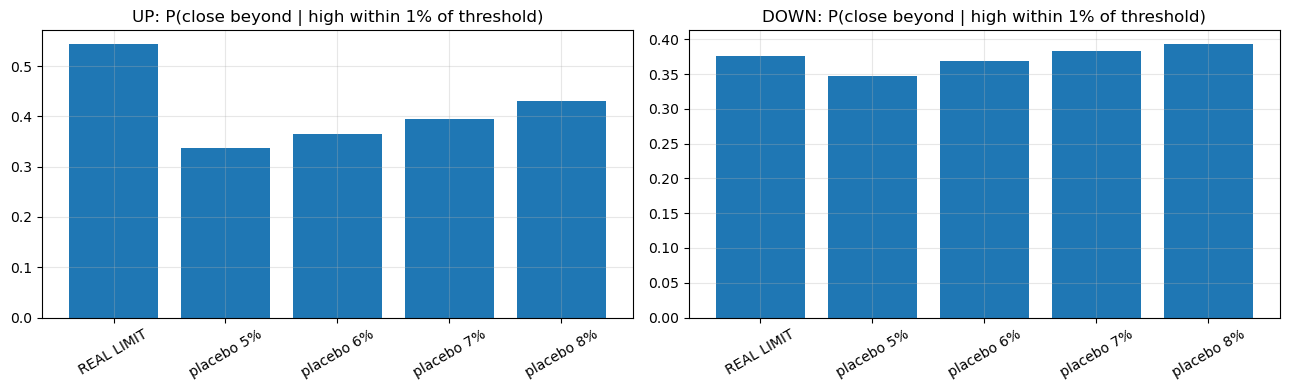

In [7]:
def conditional_pull(d, thresh, band, side="up"):
    """P(close beyond threshold | high came within `band` of it)."""
    if side == "up":
        near = d[(d.r_high >= thresh - band)]
        if len(near) < 50: return np.nan, 0
        return (near.r >= thresh).mean(), len(near)
    near = d[(d.r_low <= -(thresh - band))]
    if len(near) < 50: return np.nan, 0
    return (near.r <= -thresh).mean(), len(near)

BAND = 0.01
rows = []
for side in ("up", "dn"):
    d = px
    # real bound, using each stock-day's own realised limit
    if side == "up":
        near = d[d.d_up <= BAND]; p_real = near.close_up.mean(); n_real = len(near)
    else:
        near = d[d.d_dn <= BAND]; p_real = near.close_dn.mean(); n_real = len(near)
    rows.append({"side": side, "threshold": "REAL LIMIT", "n": n_real, "P(close beyond)": p_real})
    for th in (0.05, 0.06, 0.07, 0.08):
        p, n = conditional_pull(d, th, BAND, side)
        rows.append({"side": side, "threshold": f"placebo {th:.0%}", "n": n, "P(close beyond)": p})
out = pd.DataFrame(rows)
print(f"conditional pull, band = {BAND:.1%}\n")
print(out.round(4).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, s, lab in [(ax[0], "up", "UP"), (ax[1], "dn", "DOWN")]:
    sub = out[out.side == s]
    a.bar(sub.threshold, sub["P(close beyond)"])
    a.set_title(f"{lab}: P(close beyond | high within 1% of threshold)")
    a.tick_params(axis="x", rotation=30)
plt.tight_layout()

UP side, by proximity band:
band   REAL  n_real  placebo5%  placebo6%  placebo7%  placebo8%
3.0% 0.3249   87439     0.1276     0.1605     0.1953     0.2345
2.0% 0.4225   67235     0.2169     0.2498     0.2860     0.3244
1.5% 0.4774   59499     0.2734     0.3044     0.3386     0.3755
1.0% 0.5441   52207     0.3375     0.3658     0.3955     0.4312
0.5% 0.6241   45514     0.4112     0.4331     0.4579     0.4927


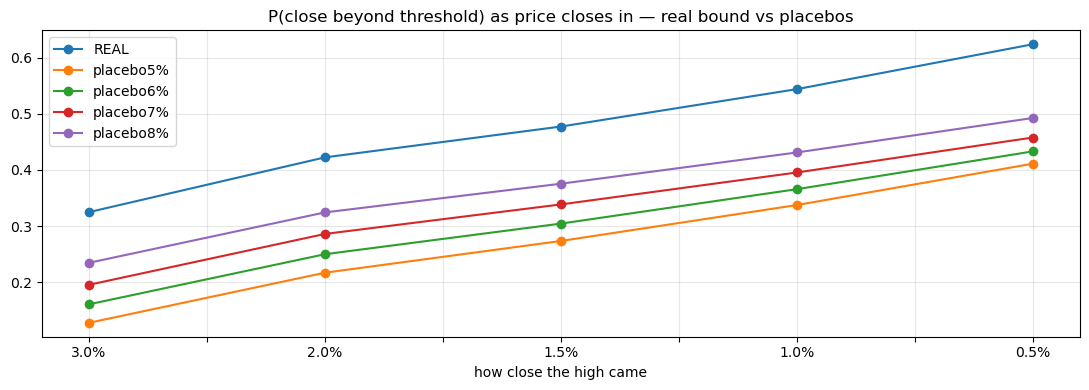

In [8]:
# Sweep the proximity band: the magnet predicts the real bound pulls away from the
# placebos as the price gets closer to it.
rows = []
for band in (0.03, 0.02, 0.015, 0.01, 0.005):
    near = px[px.d_up <= band]
    row = {"band": f"{band:.1%}", "REAL": near.close_up.mean(), "n_real": len(near)}
    for th in (0.05, 0.06, 0.07, 0.08):
        p, n = conditional_pull(px, th, band, "up")
        row[f"placebo{th:.0%}"] = p
    rows.append(row)
sw = pd.DataFrame(rows)
print("UP side, by proximity band:")
print(sw.round(4).to_string(index=False))

ax = sw.set_index("band")[[c for c in sw.columns if c.startswith(("REAL","placebo"))]].plot(
    marker="o", title="P(close beyond threshold) as price closes in — real bound vs placebos")
ax.set_xlabel("how close the high came"); plt.tight_layout()

### 6b. Extrapolating the placebo trend — the fair comparison

**Why the raw table overstates the effect.** The placebo pull **rises monotonically with
the threshold**: a stock whose high reaches within 1% of 8% closes beyond 8% more often
than the equivalent stock at 5% does. That is not a magnet, it is simply that larger
moves have more momentum behind them. So comparing the real bound (~9.8%) against the
8% placebo is unfair — some of the gap is just this trend continuing.

**The fair test** fits the placebo relationship across thresholds and extrapolates it to
the mean realised limit return, then asks whether the real bound sits **above its own
extrapolated placebo trend**. Only that excess is attributable to the limit rule itself.

In [9]:
mean_lim = px.lim_r_up.mean()
print(f"mean realised UP-limit return = {mean_lim:.4%}\n")

rows = []
for band in (0.03, 0.02, 0.015, 0.01, 0.005):
    ths = np.array([0.05, 0.06, 0.07, 0.08])
    ps = np.array([conditional_pull(px, t, band, "up")[0] for t in ths])
    ok = ~np.isnan(ps)
    slope, intercept = np.polyfit(ths[ok], ps[ok], 1)
    predicted = intercept + slope * mean_lim
    near = px[px.d_up <= band]
    actual = near.close_up.mean()
    n = len(near)
    se = np.sqrt(actual * (1 - actual) / n)
    rows.append({"band": f"{band:.1%}", "n": n, "actual": actual,
                 "placebo_extrap": predicted, "excess_pp": (actual - predicted) * 100,
                 "z": (actual - predicted) / se})
ex = pd.DataFrame(rows)
print("UP side — real bound vs its own extrapolated placebo trend:")
print(ex.round(4).to_string(index=False))

rows = []
for band in (0.03, 0.02, 0.015, 0.01, 0.005):
    ths = np.array([0.05, 0.06, 0.07, 0.08])
    ps = np.array([conditional_pull(px, t, band, "dn")[0] for t in ths])
    ok = ~np.isnan(ps)
    slope, intercept = np.polyfit(ths[ok], ps[ok], 1)
    predicted = intercept + slope * abs(px.lim_r_dn.mean())
    near = px[px.d_dn <= band]
    actual = near.close_dn.mean(); n = len(near)
    se = np.sqrt(actual * (1 - actual) / n)
    rows.append({"band": f"{band:.1%}", "n": n, "actual": actual,
                 "placebo_extrap": predicted, "excess_pp": (actual - predicted) * 100,
                 "z": (actual - predicted) / se})
print("\nDOWN side:")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("\nexcess_pp > 0 with large z = pull beyond what the momentum trend explains = magnet")

mean realised UP-limit return = 9.8938%



UP side — real bound vs its own extrapolated placebo trend:
band     n  actual  placebo_extrap  excess_pp       z
3.0% 87439  0.3249          0.3002     2.4674 15.5791
2.0% 67235  0.4225          0.3910     3.1506 16.5389
1.5% 59499  0.4774          0.4385     3.8930 19.0114
1.0% 52207  0.5441          0.4880     5.6085 25.7298
0.5% 45514  0.6241          0.5401     8.4032 37.0133



DOWN side:
band     n  actual  placebo_extrap  excess_pp        z
3.0% 46907  0.2017          0.2313    -2.9560 -15.9541
2.0% 33947  0.2787          0.3252    -4.6422 -19.0758
1.5% 29252  0.3235          0.3744    -5.0902 -18.6104
1.0% 25116  0.3767          0.4250    -4.8231 -15.7744
0.5% 21346  0.4433          0.4763    -3.3035  -9.7158

excess_pp > 0 with large z = pull beyond what the momentum trend explains = magnet


## 7. Intraday: the test the paper actually specifies

Cho et al. are explicit:

> *"To test the magnet effect, however, we cannot use daily prices. We must examine
> intraday price changes to see how the price reacts as it gets closer to the limits."*

Everything above is a daily-data proxy. The genuine test asks whether the **rate** of
price change increases as the distance to the bound shrinks, *within* the session.

**Data constraint, stated honestly.** Free per-stock intraday for Taiwan is thin:

| source | resolution | history |
|---|---|---|
| Yahoo | 1-minute | ~7 days |
| Yahoo | 5-minute | ~60 days |
| Yahoo | 60-minute | ~730 days (~5 bars/session) |
| FinMind minute | paywalled | — |
| TWSE tick | commercial | — |

So the intraday leg runs on a short, recent window and is a **supporting** test, not the
headline. The design: for each bar, measure distance-to-limit at the bar open and the
return over the bar, then ask whether return rises as distance falls — controlling for
momentum, since a price near the limit got there by rising, and trend continuation
alone would produce the same pattern.

In [10]:
import os
import intraday as I

bars5  = I.load_bars("data/intraday_5m.csv", px)  if os.path.exists("data/intraday_5m.csv")  else None
bars60 = I.load_bars("data/intraday_60m.csv", px) if os.path.exists("data/intraday_60m.csv") else None
for lab, b in [("5-minute", bars5), ("60-minute", bars60)]:
    if b is None:
        print(f"{lab}: no cache -- run  python3 pull_intraday.py"); continue
    print(f"{lab}: {len(b):,} bars | {b.stock_id.nunique()} stocks | "
          f"{b.date.min().date()} .. {b.date.max().date()} | "
          f"{b.groupby(['stock_id','date']).size().median():.0f} bars/session")

5-minute: 179,024 bars | 60 stocks | 2026-07-02 .. 2026-09-23 | 53 bars/session
60-minute: 207,744 bars | 59 stocks | 2023-09-22 .. 2026-09-23 | 5 bars/session


### 7a. Does the price speed up as the bound approaches?

**What this does.** Splits bars by how far the bar's **open** sits from the day's limit,
and reports both the **signed** mean bar return (direction) and the **mean absolute**
bar return (speed). A magnet requires *both* to rise as the distance falls.

Bars where the stock is locked at the bound are near-motionless by construction, so the
innermost band is reported separately and should not be read as "slow trading".


===== 5-minute — UP bound =====
         band     n  mean_r_bp      t  mean_abs_bp
[0.040,0.050)  4887       1.83   1.70        47.57
[0.030,0.040)  4004       0.90   0.73        49.91
[0.020,0.030)  3233      -1.17  -0.96        45.80
[0.015,0.020)  1325      -1.30  -0.73        44.55
[0.010,0.015)  1154      -8.12  -4.57        42.26
[0.005,0.010)   992      -6.82  -4.04        36.37
[0.000,0.005) 11627      -2.21 -12.00         3.54

===== 5-minute — DOWN bound =====
         band    n  mean_r_bp     t  mean_abs_bp
[0.040,0.050) 5679       1.98  2.30        40.87
[0.030,0.040) 3940       2.24  1.98        45.22
[0.020,0.030) 2971       1.93  1.51        46.82
[0.015,0.020) 1235      -0.61 -0.30        48.04
[0.010,0.015) 1204      -2.68 -1.44        43.39
[0.005,0.010) 1061      -3.36 -1.78        38.95
[0.000,0.005) 5750      -3.71 -9.44         7.75

===== 60-minute — UP bound =====
         band    n  mean_r_bp      t  mean_abs_bp
[0.040,0.050) 3549      -2.68  -0.88       120.0

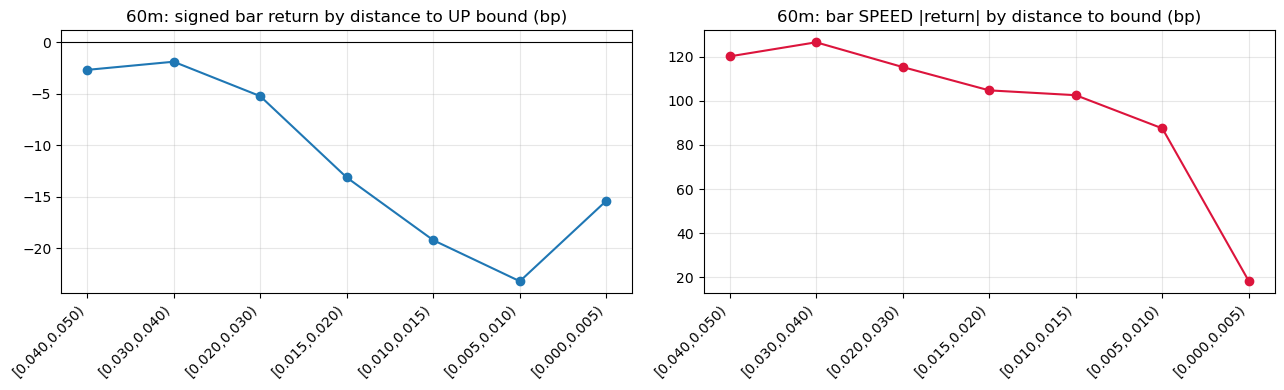

In [11]:
for lab, b in [("5-minute", bars5), ("60-minute", bars60)]:
    if b is None: continue
    print(f"\n===== {lab} — UP bound =====")
    print(I.band_profile(b, "up").round(2).to_string(index=False))
    print(f"\n===== {lab} — DOWN bound =====")
    print(I.band_profile(b, "dn").round(2).to_string(index=False))

if bars60 is not None:
    prof = I.band_profile(bars60, "up")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(range(len(prof)), prof.mean_r_bp, "o-")
    ax[0].axhline(0, c="k", lw=.8); ax[0].set_xticks(range(len(prof)))
    ax[0].set_xticklabels(prof.band, rotation=45, ha="right")
    ax[0].set_title("60m: signed bar return by distance to UP bound (bp)")
    ax[1].plot(range(len(prof)), prof.mean_abs_bp, "o-", color="crimson")
    ax[1].set_xticks(range(len(prof))); ax[1].set_xticklabels(prof.band, rotation=45, ha="right")
    ax[1].set_title("60m: bar SPEED |return| by distance to bound (bp)")
    plt.tight_layout()

### 7b. Acceleration regression, momentum-controlled, with placebo

`prox` is defined so that **positive means the price moves faster toward the bound as it
gets closer** — the magnet prediction. Momentum enters explicitly through the previous
bar's return and the return so far that session, because a price near the bound got
there by moving and trend continuation alone would mimic a magnet.

The placebo rows repeat the identical regression on the identical bars, measuring
distance to a threshold with no regulatory standing. If the real bound is not visibly
different from the placebos, there is no magnet.

In [12]:
for lab, b in [("5-minute", bars5), ("60-minute", bars60)]:
    if b is None: continue
    print(f"\n================ {lab} ================")
    for side in ("up", "dn"):
        out = I.acceleration_regression(b, side=side)
        if out is None:
            print(f"{side}: too few bars"); continue
        fit, n = out
        print(f"\n{side.upper()} bound   n={n:,}")
        print(f"   prox      {fit.params['prox']:+8.2f} bp per 1pp closer   t={fit.tvalues['prox']:+6.2f}")
        print(f"   mom_prev  {fit.params['mom_prev']:+8.4f}                     t={fit.tvalues['mom_prev']:+6.2f}")
        print(f"   mom_sofar {fit.params['mom_sofar']:+8.4f}                     t={fit.tvalues['mom_sofar']:+6.2f}")
        for ps in (0.06, 0.07, 0.08):
            o = I.acceleration_regression(b, side=side, pseudo=ps)
            if o:
                print(f"     placebo {ps:.0%}   prox {o[0].params['prox']:+7.2f}   t={o[0].tvalues['prox']:+6.2f}")


================ 5-minute ================



UP bound   n=27,114
   prox         -2.20 bp per 1pp closer   t= -0.64
   mom_prev   -0.0205                     t= -2.19
   mom_sofar  +0.0134                     t= +0.39


     placebo 6%   prox   +1.07   t= +1.99
     placebo 7%   prox   +0.19   t= +0.35
     placebo 8%   prox   -0.77   t= -1.58

DN bound   n=21,775
   prox         -9.16 bp per 1pp closer   t= -1.83
   mom_prev   +0.0056                     t= +0.47
   mom_sofar  +0.0781                     t= +1.57
     placebo 6%   prox   -0.40   t= -1.00


     placebo 7%   prox   -0.91   t= -1.96


     placebo 8%   prox   -0.32   t= -0.64

================ 60-minute ================



UP bound   n=14,334
   prox         -6.93 bp per 1pp closer   t= -0.85
   mom_prev   -0.0226                     t= -4.11
   mom_sofar  +0.0399                     t= +0.49
     placebo 6%   prox   +3.05   t= +3.17
     placebo 7%   prox   +0.32   t= +0.26
     placebo 8%   prox   -2.27   t= -1.32

DN bound   n=9,151
   prox        -40.76 bp per 1pp closer   t= -2.07
   mom_prev   -0.0169                     t= -2.05
   mom_sofar  +0.3442                     t= +1.74
     placebo 6%   prox   -3.84   t= -3.63


     placebo 7%   prox   -4.06   t= -3.56
     placebo 8%   prox   -5.25   t= -3.87


## 8. What happens after a limit hit

**What this does.** Measures the return on the following days after a limit touch and
after a limit close, split by direction.

**Why it belongs here.** It separates the two competing readings of the limit. Under the
**overreaction** view the limit interrupts a mispricing, so the next day should
*reverse*. Under the **delayed price discovery** view the limit merely postpones a move
that is genuinely warranted, so the next day should *continue*.

**The fill trap, which is the whole point of this section.** A close-to-close return
after a limit close is **not capturable**. A stock locked at its up limit has unfilled
buy demand at that price — that is what "locked" means — so you cannot buy there. The
entire move shows up as an opening gap the next morning, before any entry is possible.
Below we split the forward return into the **overnight gap** (unreachable) and the
**open-to-close** leg (the only part actually tradable), and Taiwan's 30bp sale tax is
applied to the latter.

In [13]:
d = px.sort_values(["stock_id","date"]).copy()
g = d.groupby("stock_id")
d["next_open"]  = g.open.shift(-1)
d["next_close"] = g.close.shift(-1)

# Decompose the next-day move into what you cannot capture and what you can.
d["gap"]    = d.next_open / d.close - 1          # overnight: NOT tradable after a lock
d["o2c"]    = d.next_close / d.next_open - 1     # open-to-close: the tradable leg
d["c2c"]    = d.next_close / d.close - 1         # the naive (misleading) number

TAX_BP = 30.0   # Taiwan securities transaction tax, on sale
COST_BP = TAX_BP + 5 + 10

rows = []
for lab, mask in [("close AT up limit", d.close_up),
                  ("touched up, closed off", d.touch_up & ~d.close_up),
                  ("close AT down limit", d.close_dn),
                  ("touched down, closed off", d.touch_dn & ~d.close_dn)]:
    sub = d[mask].dropna(subset=["gap","o2c","c2c"])
    if not len(sub): continue
    row = {"event": lab, "n": len(sub)}
    for k, col in [("c2c(naive)","c2c"), ("gap(unreachable)","gap"), ("o2c(tradable)","o2c")]:
        x = sub[col]
        row[k] = x.mean()*1e4
        row[k+"_t"] = x.mean()/x.std()*np.sqrt(len(x))
    row["o2c net of cost"] = sub.o2c.mean()*1e4 - COST_BP
    rows.append(row)
post = pd.DataFrame(rows)

print("next-day return decomposition, bp:")
print(post[["event","n","c2c(naive)","gap(unreachable)","o2c(tradable)","o2c net of cost"]]
      .round(1).to_string(index=False))
print("\nt-stats:")
print(post[["event","c2c(naive)_t","gap(unreachable)_t","o2c(tradable)_t"]].round(2).to_string(index=False))
print(f"\ncost assumed: {COST_BP:.0f}bp round trip (30bp TW sale tax + 5bp commission + 10bp spread)")
print("the naive c2c number assumes a fill at a LOCKED limit close, which is impossible.")

next-day return decomposition, bp:
                   event     n  c2c(naive)  gap(unreachable)  o2c(tradable)  o2c net of cost
       close AT up limit 28390       204.5             252.7          -43.3            -88.3
  touched up, closed off 10873       -34.2               1.8          -34.1            -79.1
     close AT down limit  9439      -131.9            -168.2           43.6             -1.4
touched down, closed off  7864        40.4               9.3           34.5            -10.5

t-stats:
                   event  c2c(naive)_t  gap(unreachable)_t  o2c(tradable)_t
       close AT up limit         59.30              103.15           -15.03
  touched up, closed off         -5.90                0.37            -8.63
     close AT down limit        -10.26              -13.47             8.56
touched down, closed off          5.38                1.48             6.59

cost assumed: 45bp round trip (30bp TW sale tax + 5bp commission + 10bp spread)
the naive c2c number assumes 

## 9. Verdict — the daily and intraday evidence disagree

| # | Test | Magnet would require | Result |
|---|------|----------------------|--------|
| 3 | Density approaching the bound | Hollowing in the last stretch | Upside thinner than downside |
| 4 | Extrapolation from the interior | Observed **below** extrapolated | **Against** — above on both sides |
| 5 | Up/down asymmetry | Upside hole deeper | **For** — z = −5.7 in the final band |
| 6 | Placebo-trend excess | Real bound pulls harder than placebos | **For (up)**, reversed (down) |
| 7 | **Intraday acceleration** | Bar return and speed rise as distance falls | **Against** — both fall |
| 8 | Post-limit behaviour | (diagnostic) | Continuation is entirely an unreachable gap |

**How to read the conflict.** The daily and intraday tests ask different questions:

- *daily*: given the high came within x of the bound, does the day **close** there?
- *intraday*: given the price is near the bound **now**, does it move toward it faster?

The daily test conditions on an outcome that is itself selected on a large move, so a
steeply rising momentum relationship near the bound can masquerade as a magnet — and the
placebo trend is extrapolated **linearly**, which will understate that curvature. The
intraday test has no such problem: it compares a stock with itself, within the session,
with momentum controlled.

The paper is explicit that the intraday test is the valid one. It says **no magnet** —
and in fact the reverse, with bar returns turning progressively more negative and price
speed falling as the bound approaches. That is consistent with
[Chang & Chang](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3942000), who report
the magnet effect disappears once the limit is relaxed.

**Limits of the intraday evidence, stated plainly.** 56–60 stocks selected as frequent
limit-approachers; 5-minute covers ~60 days, 60-minute ~2 years at only ~5 bars a
session. Short and coarse. It is the more valid design on a weaker sample, against a
less valid design on 2.3m stock-days. That tension is the honest state of the result and
should be reported, not resolved by picking the answer one prefers.

**What would settle it:** real tick or 1-minute data over several years — TWSE sells it,
TEJ carries it. That is the one purchase that would turn this into a publishable answer.

**Reminders carried from the earlier Taiwan studies**

1. The spike at the bound is **censoring**, not evidence. Only the approach shape counts.
2. A price near the limit got there by moving — **always control for momentum**, or
   trend continuation will be mistaken for a magnet.
3. If anything looks tradable, check the **lag structure** first, then Taiwan's **30bp
   sale tax**. Both killed earlier candidates that looked strong in-sample.
4. A close-to-close return after a limit close is not capturable. Decompose into the
   overnight gap and the open-to-close leg before believing any backtest.